# Binocular Overlap Sweep — Rollout Analysis

Loads checkpoints from 6 binocular overlap conditions, runs policy rollouts,
and compares performance, kinematics, reward, and CNN activation patterns.

| Condition | Checkpoint | eye_angle_offset | Overlap (°) |
|-----------|-----------|-----------------|-------------|
| overlap_80 | 260318_182135 | 0.0 | 80 |
| overlap_57 | 260319_011932 | 0.2 | 57 |
| overlap_50 | 260319_081829 | 0.262 | 50 |
| overlap_40 | 260319_223607 | 0.349 | 40 |
| overlap_20 | 260320_053802 | 0.524 | 20 |
| overlap_0  | 260320_124131 | 0.698 | 0 |

In [1]:
import os

os.environ["MUJOCO_GL"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import gc
import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from omegaconf import OmegaConf
from orbax import checkpoint as ocp
from scipy import stats
from sklearn.decomposition import PCA

from track_mjx.agent import checkpointing
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.ff_ppo.vision_encoder import VisionEncoder
from track_mjx.agent.observation_utils import (
    get_obs_sizes,
    init_dict_normalizer,
    normalize_dict_obs,
)
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays

from vnl_playground import naccdmax_patch
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import HighLevelWrapper, PriorHighLevelWrapper
from vnl_playground.tasks.rodent.run_gap_vision import RunGapVision, default_config
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP

[naccdmax_patch] Patched warp make_data/put_data: naccdmax defaults to naconmax


In [3]:
BASE_DIR = Path("/home/talmolab/Desktop/SalkResearch/vnl-playground")
CHECKPOINT_BASE = BASE_DIR / "highlvl_checkpoints"

CONDITIONS = [
    ("overlap_80", "260318_182135", 0.0, 80),
    ("overlap_57", "260319_011932", 0.2, 57),
    ("overlap_50", "260319_081829", 0.262, 50),
    ("overlap_40", "260319_223607", 0.349, 40),
    ("overlap_20", "260320_053802", 0.524, 20),
    ("overlap_0", "260320_124131", 0.698, 0),
]

EPISODE_LENGTH = 1000
N_ENVS = 512  # Parallel environments for batched rollouts
SEED = 42

CONDITION_COLORS = {
    "overlap_80": "#1976D2",
    "overlap_57": "#388E3C",
    "overlap_50": "#F57C00",
    "overlap_40": "#D32F2F",
    "overlap_20": "#7B1FA2",
    "overlap_0": "#455A64",
}

In [4]:
# (Batched rendering is handled by JaxVisionRenderer with nworld=N_ENVS
# and jax.vmap for env.reset/step — no manual batch dim needed.)

In [5]:
def load_checkpoint(checkpoint_dir, condition_name):
    """Load config, env, decoder, policy network, and params from a checkpoint.

    Creates a batched eval pipeline with N_ENVS parallel worlds using
    jax.vmap for reset/step and JaxVisionRenderer with nworld=N_ENVS.
    """
    ckpt_path = CHECKPOINT_BASE / checkpoint_dir

    # Load config
    with open(ckpt_path / "config.json") as f:
        cfg_dict = json.load(f)
    cfg = OmegaConf.create(cfg_dict)

    # Load frozen decoder (SCAMPER prior checkpoint path)
    from vnl_playground.tasks.prior_utils import (
        load_prior_checkpoint,
        make_decoder_inference_fn as make_scamper_decoder_fn,
        make_prior_inference_fn,
    )

    prior_path = cfg.transfer.prior_checkpoint_path
    prior_step = cfg.transfer.get("prior_checkpoint_step", None)
    _enc_p, _pri_p, dec_p, dec_n, prior_cfg = load_prior_checkpoint(
        prior_path, prior_step
    )
    latent_size = prior_cfg["network_config"]["intention_size"]
    decoder_policy_fn = make_scamper_decoder_fn(dec_p, dec_n, prior_cfg)
    prior_fn = make_prior_inference_fn(_pri_p, dec_n, prior_cfg)
    mimic_cfg = OmegaConf.create(prior_cfg)

    # Load environment — scale naconmax for N_ENVS worlds
    env_args = (
        OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
    )
    if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
        env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)
    # Scale naconmax proportionally: use eval_naconmax/num_eval_envs as per-world budget
    eval_naconmax = cfg.train_setup.train_config.get("eval_naconmax", 2560)
    num_eval_envs = cfg.train_setup.train_config.get("num_eval_envs", 128)
    per_world_ncon = eval_naconmax / num_eval_envs
    env_args["naconmax"] = max(256, int(per_world_ncon * N_ENVS))
    raw_env = tasks.load(
        cfg.env_config.env_name,
        flatten_obs=False,
        config_overrides=env_args,
    )

    # Get obs_sizes
    highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
    decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")
    _tmp = PriorHighLevelWrapper(
        raw_env,
        prior_fn,
        decoder_policy_fn,
        latent_size,
        highlvl_obs_key=highlvl_obs_key,
        decoder_obs_key=decoder_obs_key,
        pass_vision=True,
        pass_task_obs=True,
    )
    _tmp_state = _tmp.reset(jax.random.PRNGKey(99))
    obs_sizes = get_obs_sizes(_tmp_state.obs)
    del _tmp, _tmp_state

    # Recreate PPO network
    mono_channels = 1 if cfg.env_config.get("grayscale", True) else 3
    network_fn_name = cfg.network_config.get("arch_name", "shared_vision_task_obs")
    n_channels = 2 * mono_channels if "binocular" in network_fn_name else mono_channels
    vision_shape = (
        cfg.env_config.get("vision_height", 32),
        cfg.env_config.get("vision_width", 32),
        n_channels,
    )

    if "binocular" in network_fn_name:
        binocular_mode = cfg.network_config.get("binocular_mode", "shared")
        shared_weights = binocular_mode == "shared"
        ppo_network, shared_module = (
            ff_ppo_networks.make_binocular_shared_vision_task_obs_highlvl_ppo_networks(
                obs_sizes=obs_sizes,
                action_size=latent_size,
                vision_shape=vision_shape,
                vision_latent_size=cfg.network_config.vision_latent_size,
                vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
                decoder_hidden_layer_sizes=tuple(
                    cfg.network_config.decoder_hidden_layer_sizes
                ),
                value_hidden_layer_sizes=tuple(
                    cfg.network_config.value_hidden_layer_sizes
                ),
                vision_channels=tuple(cfg.network_config.vision_channels),
                fusion_hidden_layer_sizes=tuple(
                    cfg.network_config.get("fusion_hidden_layer_sizes", [256])
                ),
                shared_weights=shared_weights,
            )
        )
    else:
        ppo_network, shared_module = (
            ff_ppo_networks.make_shared_vision_task_obs_highlvl_ppo_networks(
                obs_sizes=obs_sizes,
                action_size=latent_size,
                vision_shape=vision_shape,
                vision_latent_size=cfg.network_config.vision_latent_size,
                vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
                decoder_hidden_layer_sizes=tuple(
                    cfg.network_config.decoder_hidden_layer_sizes
                ),
                value_hidden_layer_sizes=tuple(
                    cfg.network_config.value_hidden_layer_sizes
                ),
                vision_channels=tuple(cfg.network_config.vision_channels),
                fusion_hidden_layer_sizes=tuple(
                    cfg.network_config.get("fusion_hidden_layer_sizes", [256])
                ),
            )
        )

    # Restore checkpoint
    ckpt_mgr = ocp.CheckpointManager(
        str(ckpt_path),
        options=ocp.CheckpointManagerOptions(
            save_interval_steps=1,
            max_to_keep=200,
            step_prefix="PPONetwork",
            create=False,
        ),
    )
    latest_step = ckpt_mgr.latest_step()
    key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
    init_policy_params = ppo_network.policy_network.init(key_policy)
    dummy_obs = {
        "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
        "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
    }
    abstract_policy = _replace_zero_sized_arrays(
        (init_dict_normalizer(dummy_obs), init_policy_params)
    )
    normalizer_params, policy_params = ckpt_mgr.restore(
        latest_step,
        args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
    )["policy"]
    params_tuple = (normalizer_params, policy_params)

    # Binocular vision renderers with nworld=N_ENVS
    left_cam = cfg.env_config.get("left_camera_name", "eye_left-rodent")
    right_cam = cfg.env_config.get("right_camera_name", "eye_right-rodent")
    vw = cfg.env_config.get("vision_width", 32)
    vh = cfg.env_config.get("vision_height", 32)
    gs = cfg.env_config.get("grayscale", True)

    left_renderer = JaxVisionRenderer(
        mj_model=raw_env.mj_model,
        mjx_model=raw_env.mjx_model,
        nworld=N_ENVS,
        width=vw,
        height=vh,
        grayscale=gs,
        camera_name=left_cam,
    )
    right_renderer = JaxVisionRenderer(
        mj_model=raw_env.mj_model,
        mjx_model=raw_env.mjx_model,
        nworld=N_ENVS,
        width=vw,
        height=vh,
        grayscale=gs,
        camera_name=right_cam,
    )

    # PriorHighLevelWrapper: policy outputs residual added to prior mean
    eval_env = PriorHighLevelWrapper(
        raw_env,
        prior_fn,
        decoder_policy_fn,
        latent_size,
        highlvl_obs_key=highlvl_obs_key,
        decoder_obs_key=decoder_obs_key,
        pass_vision=True,
        pass_task_obs=True,
    )

    # Batched eval functions: vmap reset/step, render binocular for all worlds
    vmapped_reset = jax.vmap(eval_env.reset)
    vmapped_step = jax.vmap(eval_env.step)

    def _inject_vision(obs, vision):
        """Replace vision placeholder in obs dict with rendered images."""
        if "vision" in obs:
            return {**obs, "vision": vision}
        if "state" in obs and "vision" in obs["state"]:
            return {**obs, "state": {**obs["state"], "vision": vision}}
        return obs

    def eval_reset(rngs):
        states = vmapped_reset(rngs)
        left_img = left_renderer.render(states.data)  # (N_ENVS, H, W, C)
        right_img = right_renderer.render(states.data)  # (N_ENVS, H, W, C)
        vision = jnp.concatenate([left_img, right_img], axis=-1)  # (N_ENVS, H, W, 2C)
        return states.replace(obs=_inject_vision(states.obs, vision))

    def eval_step(states, actions):
        states = vmapped_step(states, actions)
        left_img = left_renderer.render(states.data)
        right_img = right_renderer.render(states.data)
        vision = jnp.concatenate([left_img, right_img], axis=-1)
        return states.replace(obs=_inject_vision(states.obs, vision))

    make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
    jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
    jit_eval_reset = jax.jit(eval_reset)
    jit_eval_step = jax.jit(eval_step)

    # Standalone encoder for activation extraction (single-env)
    standalone_encoder = VisionEncoder(
        feature_size=cfg.network_config.get("vision_feature_size", 32),
        channels=tuple(cfg.network_config.vision_channels),
    )
    vision_encoder_params = {"params": policy_params["params"]["vision_encoder"]}

    import mujoco

    torso_body_id = mujoco.mj_name2id(
        raw_env.mj_model, mujoco.mjtObj.mjOBJ_BODY, "torso-rodent"
    )

    print(
        f"[{condition_name}] Loaded step {latest_step}, arch={network_fn_name}, "
        f"vision={vision_shape}, n_envs={N_ENVS}"
    )

    return {
        "cfg": cfg,
        "raw_env": raw_env,
        "eval_env": eval_env,
        "left_renderer": left_renderer,
        "right_renderer": right_renderer,
        "ppo_network": ppo_network,
        "shared_module": shared_module,
        "params_tuple": params_tuple,
        "normalizer_params": normalizer_params,
        "policy_params": policy_params,
        "jit_inference_fn": jit_inference_fn,
        "jit_eval_reset": jit_eval_reset,
        "jit_eval_step": jit_eval_step,
        "obs_sizes": obs_sizes,
        "latent_size": latent_size,
        "standalone_encoder": standalone_encoder,
        "vision_encoder_params": vision_encoder_params,
        "torso_body_id": torso_body_id,
    }

In [6]:
def make_activation_extractors(
    cfg,
    policy_params,
    standalone_encoder,
    vision_encoder_params,
    shared_module,
    normalizer_params,
):
    """Create get_conv_activations and get_all_activations for a given checkpoint.

    Handles both monocular (VisionEncoder) and binocular (BinocularVisionEncoder)
    architectures. For binocular, extracts activations from the shared_cnn path
    using the left eye image only.
    """
    CHANNELS = tuple(cfg.network_config.vision_channels)
    STRIDES = (1, 1, 2, 2)
    FUSION_LAYERS = tuple(cfg.network_config.get("fusion_hidden_layer_sizes", [256]))

    # Detect binocular vs monocular from config
    is_binocular = "binocular" in cfg.network_config.get("arch_name", "")
    mono_channels = 1 if cfg.env_config.get("grayscale", True) else 3

    def get_conv_activations(image):
        """Extract per-layer spatial conv activations.

        For binocular: uses only the LEFT eye through the shared CNN.
        """
        if is_binocular:
            # Split binocular image into left eye only
            img = jnp.array(image)
            left = img[..., :mono_channels]
            x = left.reshape(1, *left.shape[-3:])
            # Params are under vision_encoder/shared_cnn/conv_i
            cnn_params = vision_encoder_params["params"]["shared_cnn"]
        else:
            x = jnp.array(image).reshape(1, *image.shape[-3:])
            cnn_params = vision_encoder_params["params"]

        layer_acts = []
        for i, (ch, stride) in enumerate(zip(CHANNELS, STRIDES)):
            kernel = cnn_params[f"conv_{i}"]["kernel"]
            bias = cnn_params[f"conv_{i}"]["bias"]
            x = (
                jax.lax.conv_general_dilated(
                    x,
                    kernel,
                    window_strides=(stride, stride),
                    padding="VALID",
                    dimension_numbers=("NHWC", "HWIO", "NHWC"),
                )
                + bias
            )
            x = jax.nn.relu(x)
            layer_acts.append(np.array(x[0]))
        return layer_acts

    def get_all_activations(obs_dict):
        """Extract CNN features, fusion hiddens, and latent z from observation.

        Uses shared_module.apply with get_activation=True for the full forward,
        then manually extracts fusion layer activations.
        """
        obs_b = {k: jnp.array(np.array(v))[None, ...] for k, v in obs_dict.items()}
        obs_normed = normalize_dict_obs(obs_b, normalizer_params)

        # Full forward pass with activation extraction
        action, latent_mean, latent_logvar, acts = shared_module.apply(
            policy_params,
            obs=obs_normed,
            key=jax.random.PRNGKey(0),
            get_activation=True,
            method="policy_forward",
        )

        # Use vision_features from the forward pass (already computed correctly
        # for both monocular and binocular architectures)
        vision_features = acts["vision_features"]

        # Manually extract fusion MLP hidden activations
        params = policy_params["params"]
        task_obs = obs_normed["imitation_target"]
        combined = jnp.concatenate([vision_features, task_obs], axis=-1)
        z = combined
        fusion_hiddens = []
        for i in range(len(FUSION_LAYERS)):
            kernel = params[f"fusion_dense_{i}"]["kernel"]
            bias = params[f"fusion_dense_{i}"]["bias"]
            z = jax.nn.silu(z @ kernel + bias)
            ln_scale = params[f"fusion_norms_{i}"]["scale"]
            ln_bias = params[f"fusion_norms_{i}"]["bias"]
            mean = jnp.mean(z, axis=-1, keepdims=True)
            var = jnp.var(z, axis=-1, keepdims=True)
            z = (z - mean) / jnp.sqrt(var + 1e-5) * ln_scale + ln_bias
            fusion_hiddens.append(np.array(z[0]))

        return {
            "cnn_features": np.array(acts["vision_features"][0]),
            "fusion_hiddens": fusion_hiddens,
            "latent_z": np.array(acts["intention"][0]),
            "task_obs": np.array(acts["task_obs"][0]),
        }

    return get_conv_activations, get_all_activations

In [7]:
def extract_gap_info(raw_env, state):
    platform_body_ids = raw_env._platform_body_ids
    platform_half_length = raw_env._platform_half_length
    start_platform_body_id = raw_env._start_platform_body_id
    start_platform_half_length = raw_env._start_platform_half_length
    plat_centers = np.array(state.data.xpos[platform_body_ids, 0])
    plat_starts = plat_centers - platform_half_length
    plat_ends = plat_centers + platform_half_length
    start_end = (
        float(state.data.xpos[start_platform_body_id, 0]) + start_platform_half_length
    )
    all_trailing_edges = np.concatenate([[start_end], plat_ends])
    gap_starts = all_trailing_edges[:-1]
    gap_ends = plat_starts
    gap_lengths = gap_ends - gap_starts
    return gap_starts, gap_ends, gap_lengths


def compute_gap_proximity(rodent_x_positions, gap_starts, gap_ends):
    gap_proximity = np.zeros(len(rodent_x_positions))
    for t, rx in enumerate(rodent_x_positions):
        min_dist = float("inf")
        for gs, ge in zip(gap_starts, gap_ends):
            if gs <= rx <= ge:
                min_dist = 0.0
            else:
                d = min(abs(rx - gs), abs(rx - ge))
                min_dist = min(min_dist, d)
        gap_proximity[t] = min_dist
    return gap_proximity

## Data Collection Loop

In [8]:
all_results = {}

for cond_name, ckpt_dir, offset, nominal_overlap in CONDITIONS:
    print(f"\n{'='*60}")
    print(f"Processing: {cond_name} (offset={offset}, overlap={nominal_overlap} deg)")
    print(f"{'='*60}")

    ckpt = load_checkpoint(ckpt_dir, cond_name)
    get_conv_acts, get_all_acts = make_activation_extractors(
        ckpt["cfg"],
        ckpt["policy_params"],
        ckpt["standalone_encoder"],
        ckpt["vision_encoder_params"],
        ckpt["shared_module"],
        ckpt["normalizer_params"],
    )

    # Reset N_ENVS parallel environments
    rngs = jax.random.split(jax.random.PRNGKey(SEED), N_ENVS)
    states = ckpt["jit_eval_reset"](rngs)
    act_rng = jax.random.PRNGKey(SEED + 1)

    # Per-step storage: lists of (N_ENVS,) arrays
    all_rewards = []
    all_dones = []
    all_torso_x = []
    all_torso_z = []
    torso_bid = ckpt["torso_body_id"]
    qpos_start = ckpt["raw_env"]._rodent_qpos_start

    # CNN activations from env 0 only (to avoid OOM)
    cnn_features_traj = []
    latent_z_traj = []
    fusion0_traj = []

    # Env 0 initial activations
    env0_obs = jax.tree.map(lambda x: x[0], states.obs)
    acts_0 = get_all_acts(env0_obs)
    cnn_features_traj.append(acts_0["cnn_features"])
    latent_z_traj.append(acts_0["latent_z"])
    fusion0_traj.append(acts_0["fusion_hiddens"][0])

    print(f"  Running {N_ENVS} envs x {EPISODE_LENGTH} steps...")
    for i in range(EPISODE_LENGTH):
        _, act_rng = jax.random.split(act_rng)
        actions, _ = ckpt["jit_inference_fn"](ckpt["params_tuple"], states.obs, act_rng)
        states = ckpt["jit_eval_step"](states, actions)

        all_rewards.append(states.reward)  # (N_ENVS,)
        all_dones.append(states.done)  # (N_ENVS,)
        all_torso_x.append(states.data.qpos[:, qpos_start - 7])  # (N_ENVS,)
        all_torso_z.append(states.data.xpos[:, torso_bid, 2])  # (N_ENVS,)

        # Activations from env 0
        env0_obs = jax.tree.map(lambda x: x[0], states.obs)
        acts = get_all_acts(env0_obs)
        cnn_features_traj.append(acts["cnn_features"])
        latent_z_traj.append(acts["latent_z"])
        fusion0_traj.append(acts["fusion_hiddens"][0])

        if (i + 1) % 200 == 0:
            mean_r = float(jnp.mean(jnp.stack(all_rewards)))
            print(f"  Step {i+1}/{EPISODE_LENGTH}, mean_reward_so_far={mean_r:.3f}")

    # Stack to (T, N_ENVS)
    rewards = np.array(jnp.stack(all_rewards))  # (T, N_ENVS)
    dones = np.array(jnp.stack(all_dones))  # (T, N_ENVS)
    torso_x = np.array(jnp.stack(all_torso_x))  # (T, N_ENVS)
    torso_z = np.array(jnp.stack(all_torso_z))  # (T, N_ENVS)

    # Compute active mask: True for steps up to (and including) first done
    cumulative_done = np.cumsum(dones, axis=0)
    active_mask = cumulative_done <= 1  # includes the done step itself

    # Per-env summary stats
    any_done = np.any(dones > 0.5, axis=0)  # (N_ENVS,)
    first_done_step = np.argmax(dones > 0.5, axis=0)  # (N_ENVS,)
    survival_steps = np.where(
        any_done, first_done_step + 1, EPISODE_LENGTH
    )  # (N_ENVS,)
    total_reward = np.sum(rewards * active_mask, axis=0)  # (N_ENVS,)

    # Gaps crossed: count how many gap trailing edges the agent passed
    # Use max forward position per env
    max_x = np.max(torso_x * active_mask + (-1e6) * (~active_mask), axis=0)  # (N_ENVS,)

    # Gap proximity for env 0 (for CNN correlation)
    torso_x_env0 = np.concatenate(
        [[float(states.data.qpos[0, qpos_start - 7])], torso_x[:, 0]]
    )
    gap_starts_0, gap_ends_0, gap_lengths_0 = extract_gap_info(
        ckpt["raw_env"], jax.tree.map(lambda x: x[0], states)
    )
    gap_proximity_0 = compute_gap_proximity(torso_x_env0, gap_starts_0, gap_ends_0)

    all_results[cond_name] = {
        "offset": offset,
        "nominal_overlap": nominal_overlap,
        # Per-env arrays (N_ENVS,)
        "survival_steps": survival_steps,
        "total_reward": total_reward,
        "max_x": max_x,
        # Time series (T, N_ENVS)
        "rewards": rewards,
        "dones": dones,
        "torso_x": torso_x,
        "torso_z": torso_z,
        "active_mask": active_mask,
        # CNN activations from env 0
        "cnn_features": np.array(cnn_features_traj),  # (T+1, feat_dim)
        "latent_z": np.array(latent_z_traj),  # (T+1, 16)
        "fusion0": np.array(fusion0_traj),
        "gap_proximity": gap_proximity_0,
    }

    print(f"  Total reward: {np.mean(total_reward):.2f} +/- {np.std(total_reward):.2f}")
    print(
        f"  Survival: {np.mean(survival_steps):.0f} +/- {np.std(survival_steps):.0f} steps"
    )
    print(f"  Max forward pos: {np.mean(max_x):.2f} +/- {np.std(max_x):.2f} m")

    del ckpt, get_conv_acts, get_all_acts, states
    gc.collect()
    jax.clear_caches()

print("\n\nAll conditions processed!")


Processing: overlap_80 (offset=0.0, overlap=80 deg)
Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.26 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.44 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.22 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.23 ms  (ca

## Performance Comparison

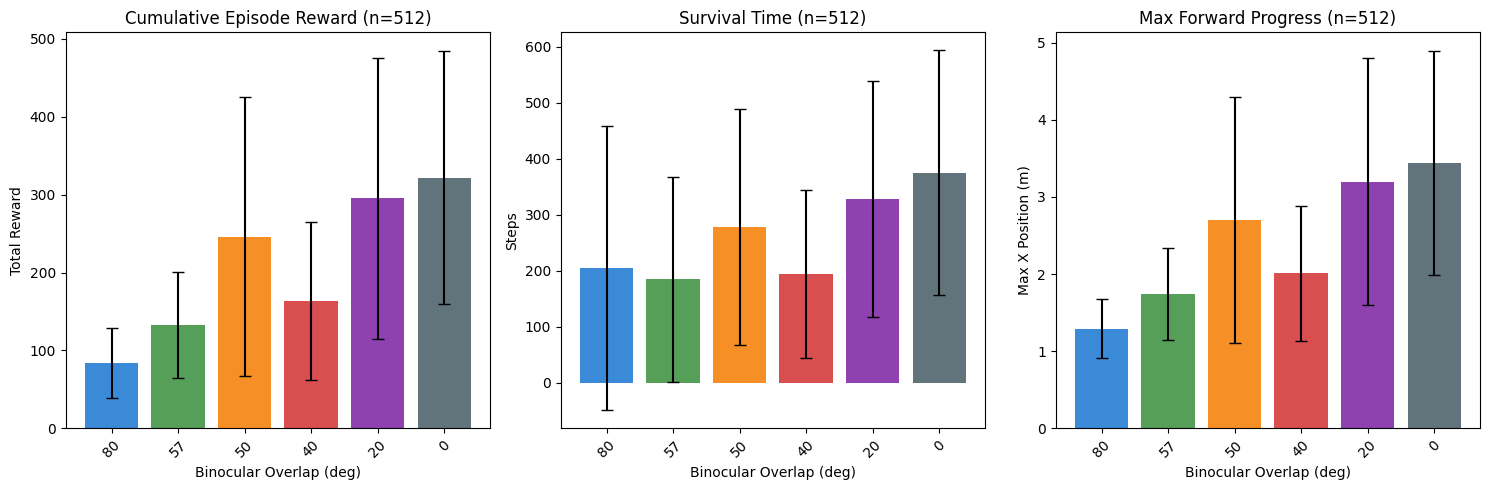

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cond_names = [c[0] for c in CONDITIONS]
colors = [CONDITION_COLORS[c] for c in cond_names]
xlabels = [f"{all_results[c]['nominal_overlap']}" for c in cond_names]
x_pos = range(len(cond_names))

# Total reward (mean +/- std)
ax = axes[0]
means = [np.mean(all_results[c]["total_reward"]) for c in cond_names]
stds = [np.std(all_results[c]["total_reward"]) for c in cond_names]
ax.bar(x_pos, means, color=colors, yerr=stds, capsize=4, alpha=0.85)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(xlabels, rotation=45)
ax.set_ylabel("Total Reward")
ax.set_title(f"Cumulative Episode Reward (n={N_ENVS})")
ax.set_xlabel("Binocular Overlap (deg)")

# Survival steps (mean +/- std)
ax = axes[1]
means = [np.mean(all_results[c]["survival_steps"]) for c in cond_names]
stds = [np.std(all_results[c]["survival_steps"]) for c in cond_names]
ax.bar(x_pos, means, color=colors, yerr=stds, capsize=4, alpha=0.85)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(xlabels, rotation=45)
ax.set_ylabel("Steps")
ax.set_title(f"Survival Time (n={N_ENVS})")
ax.set_xlabel("Binocular Overlap (deg)")

# Max forward position (mean +/- std)
ax = axes[2]
means = [np.mean(all_results[c]["max_x"]) for c in cond_names]
stds = [np.std(all_results[c]["max_x"]) for c in cond_names]
ax.bar(x_pos, means, color=colors, yerr=stds, capsize=4, alpha=0.85)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(xlabels, rotation=45)
ax.set_ylabel("Max X Position (m)")
ax.set_title(f"Max Forward Progress (n={N_ENVS})")
ax.set_xlabel("Binocular Overlap (deg)")

plt.tight_layout()
plt.show()

## Kinematics

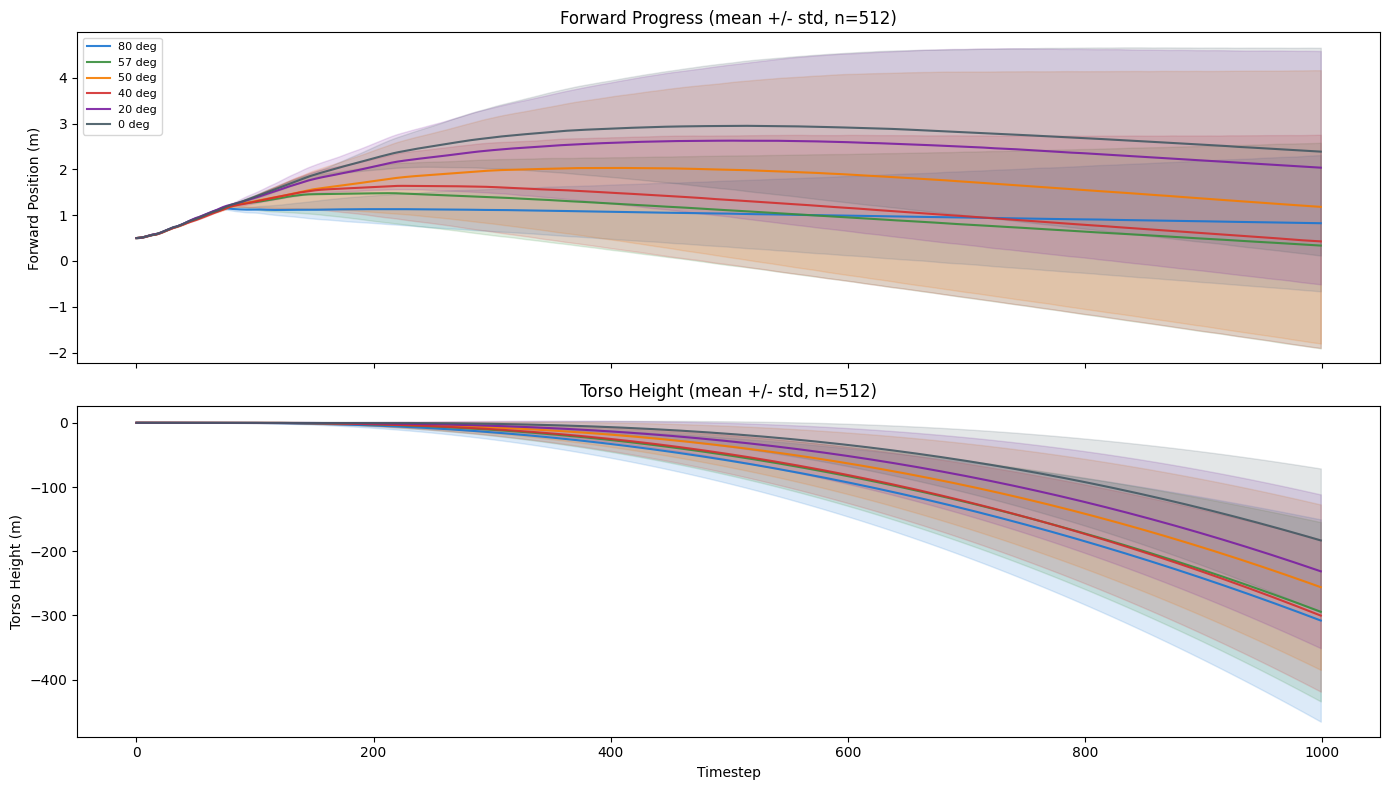

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for cond_name in cond_names:
    r = all_results[cond_name]
    t = np.arange(r["torso_x"].shape[0])
    label = f"{r['nominal_overlap']} deg"
    color = CONDITION_COLORS[cond_name]

    # Forward position: mean +/- std across N_ENVS
    mean_x = np.mean(r["torso_x"], axis=1)
    std_x = np.std(r["torso_x"], axis=1)
    axes[0].plot(t, mean_x, label=label, color=color, alpha=0.9)
    axes[0].fill_between(t, mean_x - std_x, mean_x + std_x, color=color, alpha=0.15)

    # Torso height: mean +/- std
    mean_z = np.mean(r["torso_z"], axis=1)
    std_z = np.std(r["torso_z"], axis=1)
    axes[1].plot(t, mean_z, label=label, color=color, alpha=0.9)
    axes[1].fill_between(t, mean_z - std_z, mean_z + std_z, color=color, alpha=0.15)

axes[0].set_ylabel("Forward Position (m)")
axes[0].set_title(f"Forward Progress (mean +/- std, n={N_ENVS})")
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_ylabel("Torso Height (m)")
axes[1].set_xlabel("Timestep")
axes[1].set_title(f"Torso Height (mean +/- std, n={N_ENVS})")
plt.tight_layout()
plt.show()

## Reward Trajectories

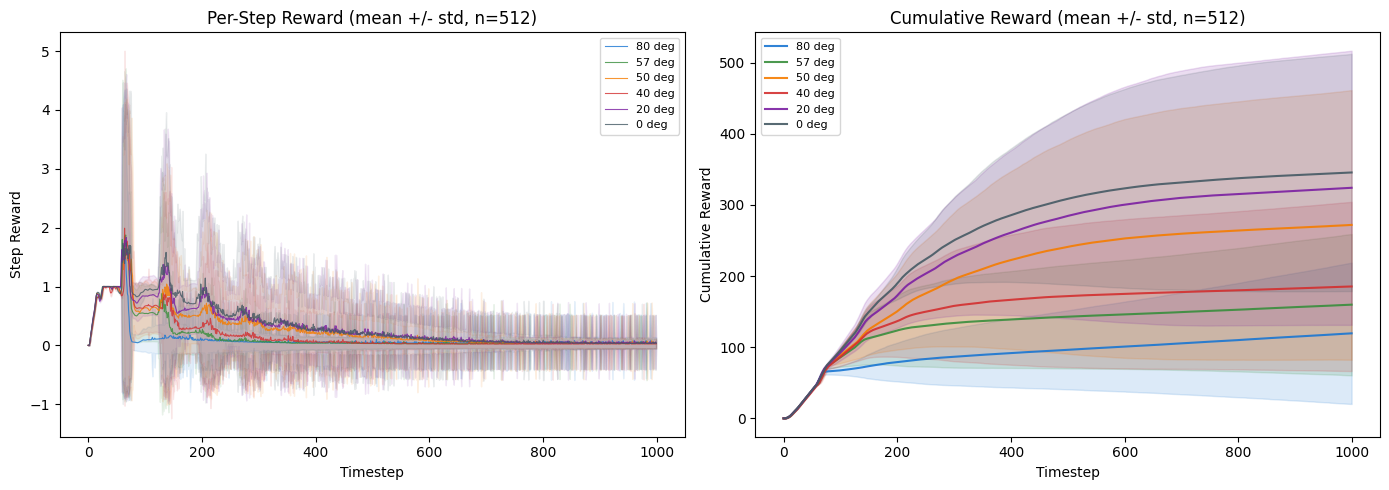

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cond_name in cond_names:
    r = all_results[cond_name]
    color = CONDITION_COLORS[cond_name]
    label = f"{r['nominal_overlap']} deg"
    t = np.arange(r["rewards"].shape[0])

    # Per-step reward: mean +/- std across N_ENVS
    mean_r = np.mean(r["rewards"], axis=1)
    std_r = np.std(r["rewards"], axis=1)
    axes[0].plot(t, mean_r, label=label, color=color, alpha=0.8, lw=0.8)
    axes[0].fill_between(t, mean_r - std_r, mean_r + std_r, color=color, alpha=0.1)

    # Cumulative reward: mean +/- std
    cum_rewards = np.cumsum(r["rewards"], axis=0)  # (T, N_ENVS)
    mean_cum = np.mean(cum_rewards, axis=1)
    std_cum = np.std(cum_rewards, axis=1)
    axes[1].plot(t, mean_cum, label=label, color=color, alpha=0.9)
    axes[1].fill_between(
        t, mean_cum - std_cum, mean_cum + std_cum, color=color, alpha=0.15
    )

axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("Step Reward")
axes[0].set_title(f"Per-Step Reward (mean +/- std, n={N_ENVS})")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Cumulative Reward")
axes[1].set_title(f"Cumulative Reward (mean +/- std, n={N_ENVS})")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## CNN Activation Analysis

In [12]:
def compute_feature_gap_correlations(features, gap_proximity):
    inv_gap_prox = 1.0 / (gap_proximity + 0.01)
    n_dims = features.shape[1]
    correlations = np.zeros(n_dims)
    p_values = np.zeros(n_dims)
    for d in range(n_dims):
        r, p = stats.pearsonr(features[:, d], inv_gap_prox)
        correlations[d] = r
        p_values[d] = p
    return correlations, p_values


cnn_correlations = {}
z_correlations = {}
for cond_name in cond_names:
    r = all_results[cond_name]
    cnn_corr, cnn_pval = compute_feature_gap_correlations(
        r["cnn_features"], r["gap_proximity"]
    )
    z_corr, z_pval = compute_feature_gap_correlations(r["latent_z"], r["gap_proximity"])
    cnn_correlations[cond_name] = (cnn_corr, cnn_pval)
    z_correlations[cond_name] = (z_corr, z_pval)

    top5 = np.argsort(np.abs(cnn_corr))[::-1][:5]
    print(f"\n{cond_name} - Top 5 gap-correlated CNN features:")
    for idx in top5:
        sig = (
            "***"
            if cnn_pval[idx] < 0.001
            else "**" if cnn_pval[idx] < 0.01 else "*" if cnn_pval[idx] < 0.05 else ""
        )
        print(f"  Feature {idx}: r={cnn_corr[idx]:.3f}, p={cnn_pval[idx]:.2e} {sig}")


overlap_80 - Top 5 gap-correlated CNN features:
  Feature 24: r=nan, p=nan 
  Feature 56: r=nan, p=nan 
  Feature 50: r=0.662, p=5.32e-127 ***
  Feature 18: r=0.654, p=2.45e-123 ***
  Feature 33: r=0.598, p=2.96e-98 ***

overlap_57 - Top 5 gap-correlated CNN features:
  Feature 43: r=0.416, p=3.85e-43 ***
  Feature 11: r=0.320, p=2.84e-25 ***
  Feature 34: r=0.275, p=6.92e-19 ***
  Feature 35: r=0.268, p=7.06e-18 ***
  Feature 2: r=0.266, p=1.29e-17 ***

overlap_50 - Top 5 gap-correlated CNN features:
  Feature 18: r=0.423, p=9.36e-45 ***
  Feature 50: r=0.373, p=2.32e-34 ***
  Feature 4: r=0.369, p=1.18e-33 ***
  Feature 36: r=0.347, p=8.98e-30 ***
  Feature 61: r=0.258, p=9.74e-17 ***

overlap_40 - Top 5 gap-correlated CNN features:
  Feature 16: r=-0.804, p=6.21e-228 ***
  Feature 15: r=0.803, p=1.51e-226 ***
  Feature 1: r=0.801, p=1.10e-224 ***
  Feature 11: r=-0.789, p=2.24e-213 ***
  Feature 48: r=-0.783, p=1.36e-208 ***

overlap_20 - Top 5 gap-correlated CNN features:
  Featur

/tmp/ipykernel_1049446/672655850.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(features[:, d], inv_gap_prox)


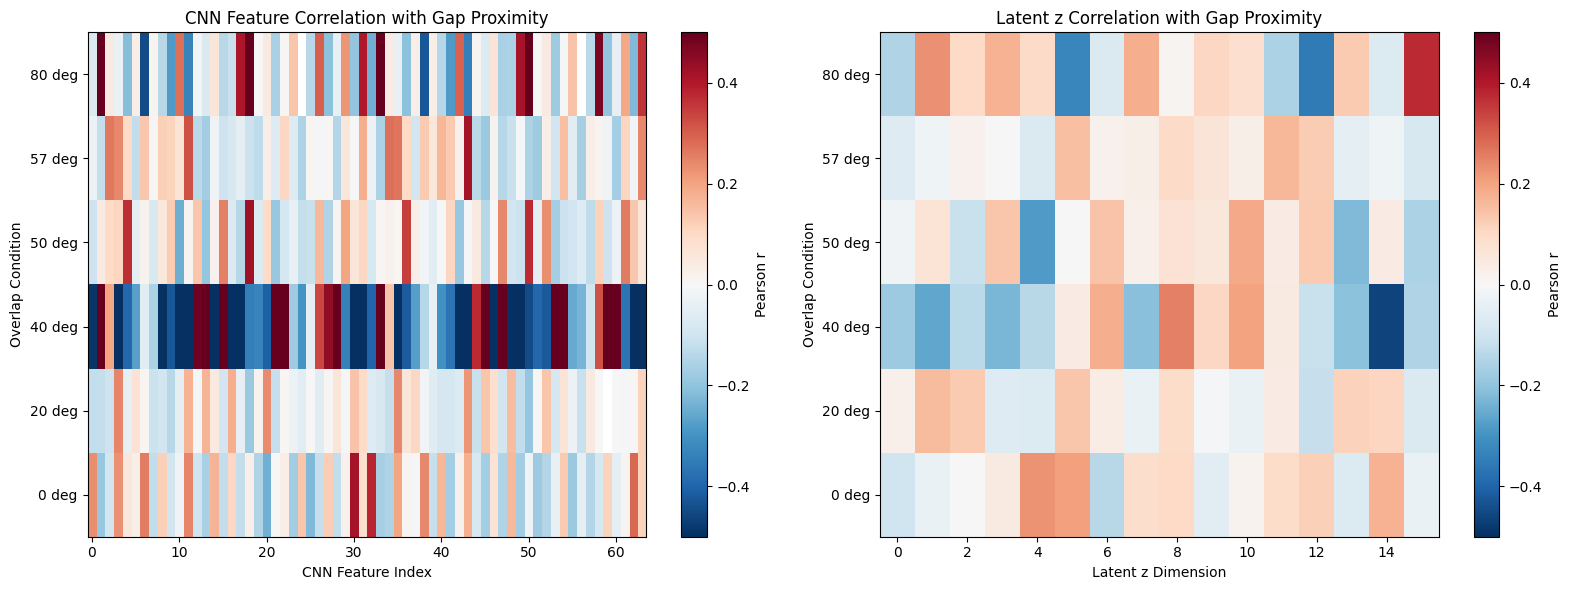

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cnn_corr_matrix = np.array([cnn_correlations[c][0] for c in cond_names])
im = axes[0].imshow(cnn_corr_matrix, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[0].set_yticks(range(len(cond_names)))
axes[0].set_yticklabels(
    [f"{all_results[c]['nominal_overlap']} deg" for c in cond_names]
)
axes[0].set_xlabel("CNN Feature Index")
axes[0].set_ylabel("Overlap Condition")
axes[0].set_title("CNN Feature Correlation with Gap Proximity")
plt.colorbar(im, ax=axes[0], label="Pearson r")

z_corr_matrix = np.array([z_correlations[c][0] for c in cond_names])
im = axes[1].imshow(z_corr_matrix, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[1].set_yticks(range(len(cond_names)))
axes[1].set_yticklabels(
    [f"{all_results[c]['nominal_overlap']} deg" for c in cond_names]
)
axes[1].set_xlabel("Latent z Dimension")
axes[1].set_ylabel("Overlap Condition")
axes[1].set_title("Latent z Correlation with Gap Proximity")
plt.colorbar(im, ax=axes[1], label="Pearson r")

plt.tight_layout()
plt.show()

/home/talmolab/Desktop/SalkResearch/mimic-mjx/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/talmolab/Desktop/SalkResearch/mimic-mjx/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_1049446/1719061257.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


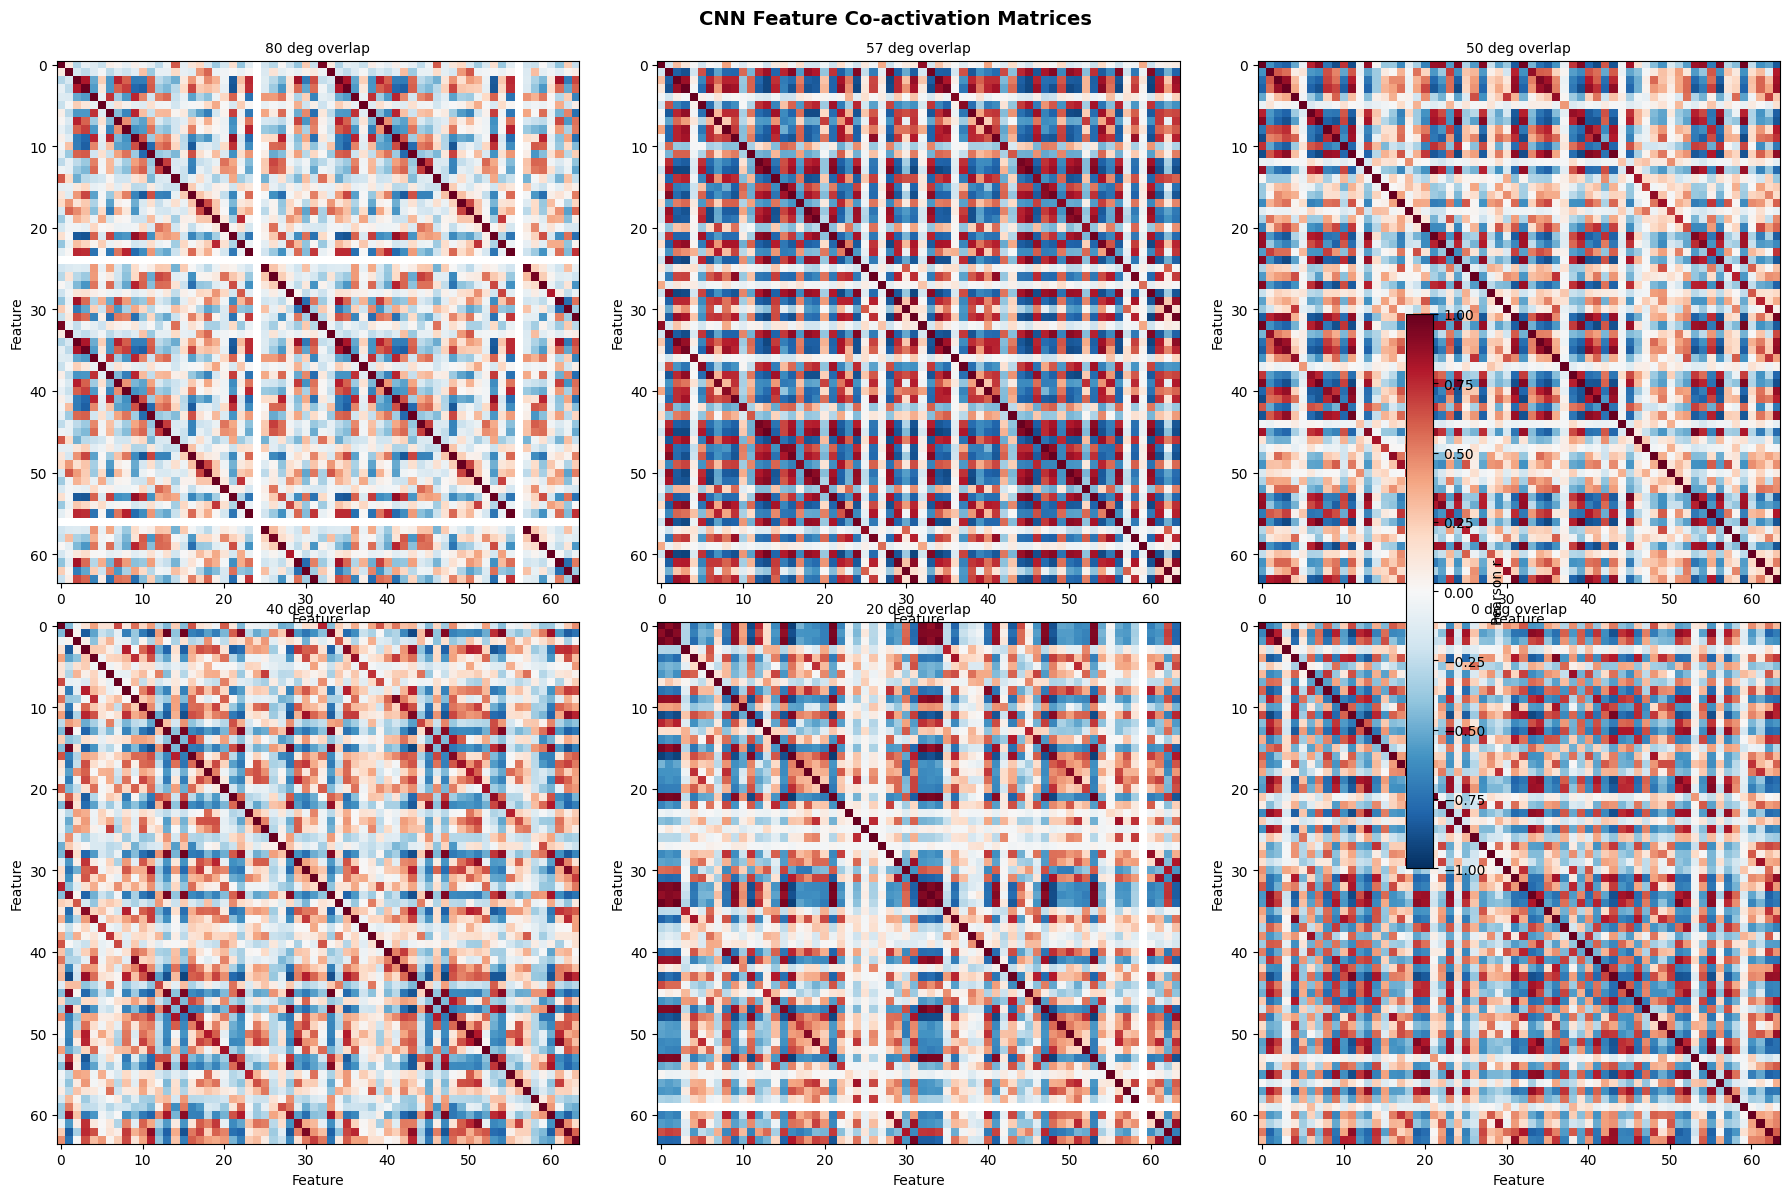

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for idx, cond_name in enumerate(cond_names):
    ax = axes[idx // 3, idx % 3]
    r = all_results[cond_name]
    corr_mat = np.corrcoef(r["cnn_features"].T)
    im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(f"{r['nominal_overlap']} deg overlap", fontsize=10)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature")

fig.suptitle("CNN Feature Co-activation Matrices", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=axes, shrink=0.6, label="Pearson r")
plt.tight_layout()
plt.show()

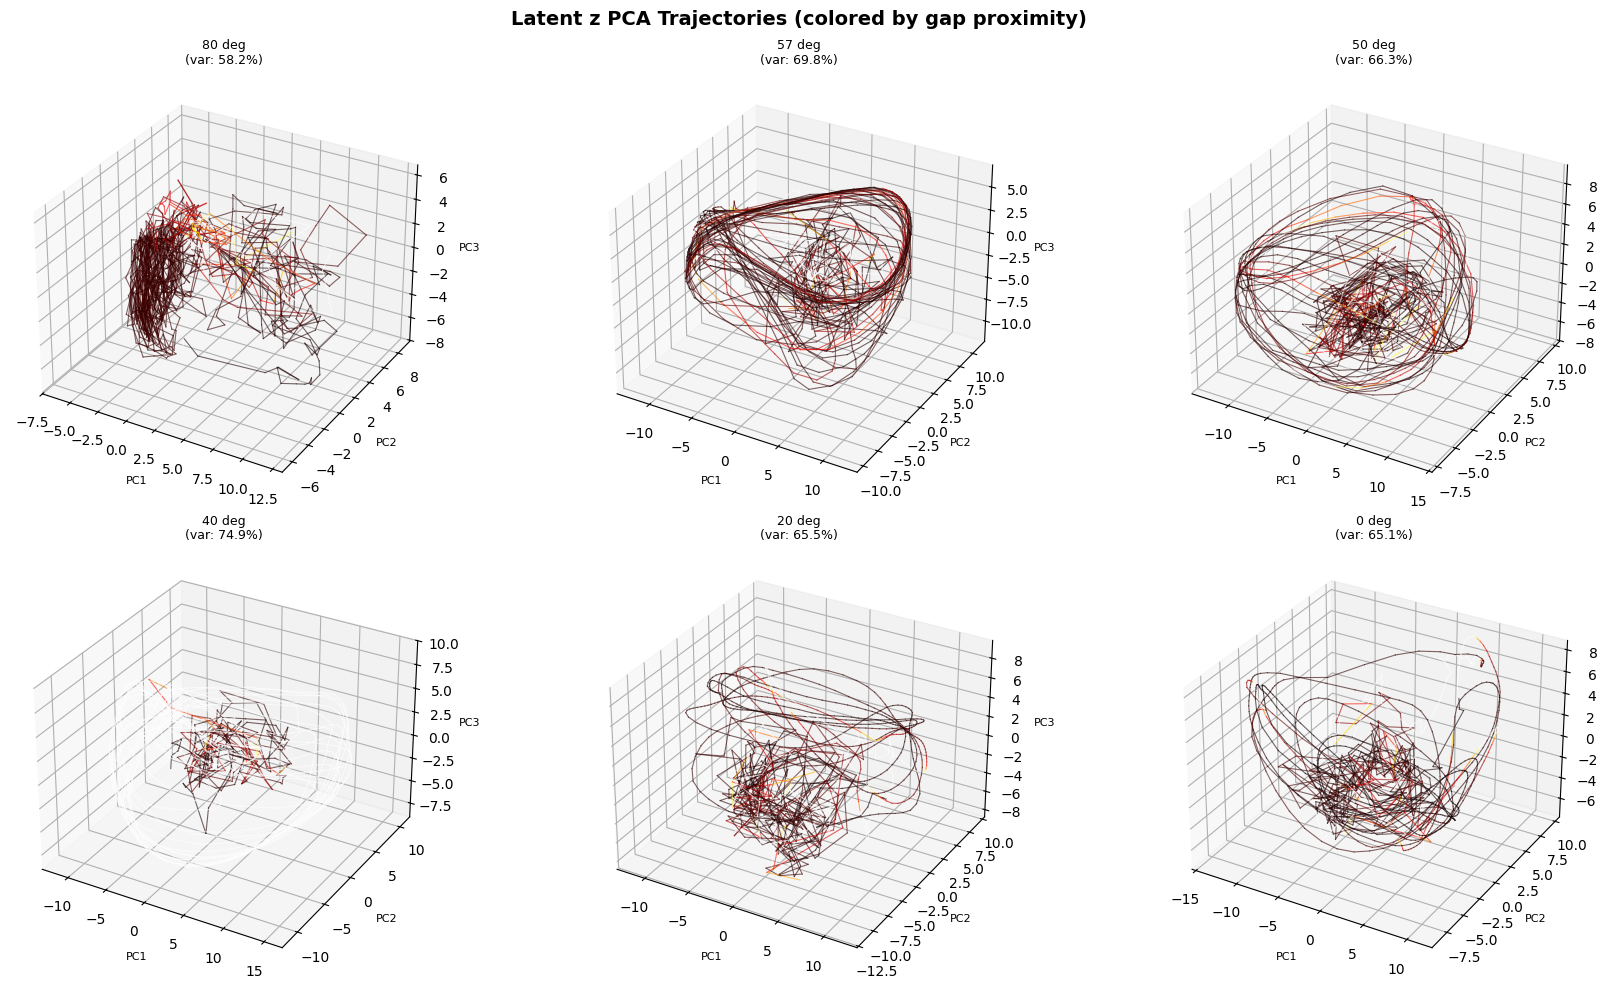

In [15]:
fig = plt.figure(figsize=(18, 10))
for idx, cond_name in enumerate(cond_names):
    ax = fig.add_subplot(2, 3, idx + 1, projection="3d")
    r = all_results[cond_name]
    z_traj = r["latent_z"]
    pca = PCA(n_components=3)
    z_pca = pca.fit_transform(z_traj)
    gap_prox = r["gap_proximity"]
    inv_prox = 1.0 / (gap_prox + 0.01)
    colors = plt.cm.hot(inv_prox / inv_prox.max())
    for i in range(len(z_pca) - 1):
        ax.plot(
            z_pca[i : i + 2, 0],
            z_pca[i : i + 2, 1],
            z_pca[i : i + 2, 2],
            color=colors[i],
            alpha=0.6,
            lw=0.8,
        )
    ax.set_title(
        f"{r['nominal_overlap']} deg\n(var: {pca.explained_variance_ratio_[:3].sum():.1%})",
        fontsize=9,
    )
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)

fig.suptitle(
    "Latent z PCA Trajectories (colored by gap proximity)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()